<a href="https://colab.research.google.com/github/saicharann4518-ai/Aiml-Training-IIIT-charan/blob/main/AIML_Module_6_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementing forward propagation and back propagation

In this lab, we implement forward and backpropagation to train an neural network from scratch for a simple binary classification problem using gradient descent. We also see how the network's training process looks like using both synthetic and real-world data from scikit-learn, including visualizations of performance and loss curves.

### Introduction to Neural Networks

Neural Networks are a subset of machine learning, inspired by the structure and function of the human brain. They are designed to recognize patterns and relationships in data through a process of learning, making them highly effective for tasks such as image recognition, natural language processing, and predictive analytics.

At their core, neural networks consist of interconnected layers of artificial neurons (nodes). These layers typically include:

*   **Input Layer:** Receives the initial data.
*   **Hidden Layers:** Perform computations and transformations on the input data. A network can have one or many hidden layers, making it a 'deep' neural network.
*   **Output Layer:** Produces the final result of the network's processing, such as a classification label or a predicted value.

Each connection between neurons has an associated **weight**, and each neuron has a **bias**. During the learning process, these weights and biases are adjusted to minimize the difference between the network's predictions and the actual target values, allowing the network to learn complex patterns and make accurate predictions.

### Forward Propagation

Forward propagation, also known as the forward pass, is the process by which a neural network takes raw input data and processes it through its layers to generate an output. This is the 'prediction' phase of the network.

The core operations involved in forward propagation for a single neuron or layer are:

1.  **Linear Transformation:** Each neuron receives inputs from the previous layer (or the input data itself). These inputs are multiplied by their respective weights, and a bias term is added. Mathematically, this can be represented as:
    $$ Z = WX + b $$
    Where:
    *   $Z$ is the weighted sum of inputs (or 'pre-activation').
    *   $W$ represents the weights connecting the previous layer to the current neuron.
    *   $X$ represents the inputs from the previous layer.
    *   $b$ is the bias term for the current neuron.

2.  **Activation Function:** The result of the linear transformation ($Z$) is then passed through an activation function (e.g., ReLU, Sigmoid, Tanh, Softmax). This non-linear function introduces non-linearity into the network, allowing it to learn complex patterns and make more sophisticated decisions than a simple linear model. The output of the activation function is the output of the current neuron or layer:
    $$ A = \text{Activation}(Z) $$

This output $A$ then serves as the input for the next layer in the network. This process continues layer by layer until the data reaches the output layer, producing the network's final prediction.

The goal of forward propagation is simply to calculate the output of the neural network given a set of inputs and current weights and biases.

### Backward Propagation

Backward propagation, commonly known as backpropagation, is the algorithm used to train neural networks. Its primary purpose is to adjust the weights and biases of the network to minimize the difference between the network's predictions and the actual target values. This optimization process makes the network learn from its errors.

Backpropagation works by calculating the gradient of the loss function with respect to each weight and bias in the network. These gradients indicate how much each parameter contributes to the error. The process involves two main steps:

1.  **Calculate the Loss and Error:** After forward propagation computes an output, this output is compared to the true label using a **loss function** (e.g., Mean Squared Error for regression, Cross-Entropy for classification). The result is a scalar value representing the error.

2.  **Propagate the Error Backward:** The error is then propagated backward through the network, from the output layer to the input layer. This is where the **chain rule of calculus** is critically applied. The chain rule allows us to calculate how much each weight and bias in each layer contributes to the total error by computing partial derivatives. Specifically, for each parameter (weight or bias), we calculate $\frac{\partial L}{\partial W}$ and $\frac{\partial L}{\partial b}$, where $L$ is the loss function.

    *   **Output Layer:** The gradients are calculated directly using the loss function and the activation function of the output layer.
    *   **Hidden Layers:** The gradients for hidden layers are calculated iteratively, propagating the error signal from the subsequent layer backward. This means the gradient for a weight in a given layer depends on the gradients of the weights in the layers after it.

Once all gradients are computed, an optimization algorithm (e.g., Gradient Descent, Adam) uses these gradients to update the weights and biases, moving them in the direction that reduces the loss. This iterative process of forward propagation (prediction), calculating loss, and backward propagation (updating parameters) is how a neural network learns.



# What we need for gradient descent
- Consider a simple MLP
    - Let us ignore non-linearities for now to keep it simpler, but it's just a tiny change subsequently
    - Given a linear transformation on our input (for simplicity instead of an affine transformation that includes a bias): $\hat y = \theta x$
        - $\theta$ is our parameters
        - $x$ is our input
        - $\hat y$ is our prediction
    - Then we have our MSE loss function $L = \frac{1}{2} (\hat y - y)^2$
- We need to calculate our partial derivatives of our loss w.r.t. our parameters to update our parameters: $\nabla_{\theta} = \frac{\delta L}{\delta \theta}$
    - With chain rule we have $\frac{\delta L}{\delta \theta} = \frac{\delta L}{\delta \hat y} \frac{\delta \hat y}{\delta \theta}$
        - $\frac{\delta L}{\delta \hat y} = (\hat y -  y)$
        - $\frac{\delta \hat y}{\delta \theta}$ is our partial derivatives of $y$ w.r.t. our parameters (our gradient)
        


# Forward and Backprop, illustrated diagramatically

- Let us assume the following MLP architecture (Note: no bias used here for simplicity)
    - MLP architecture
        1. Linear function: hidden size = 32
        2. Non-linear function: sigmoid
        3. Linear function: output size = 1
        4. Non-linear function: sigmoid
    - We will be going through a binary classification problem classifying 2 types of flowers
        - Output size: 1 (represented by 0 or 1 depending on the flower)
        - Input size: 2 (features of the flower)


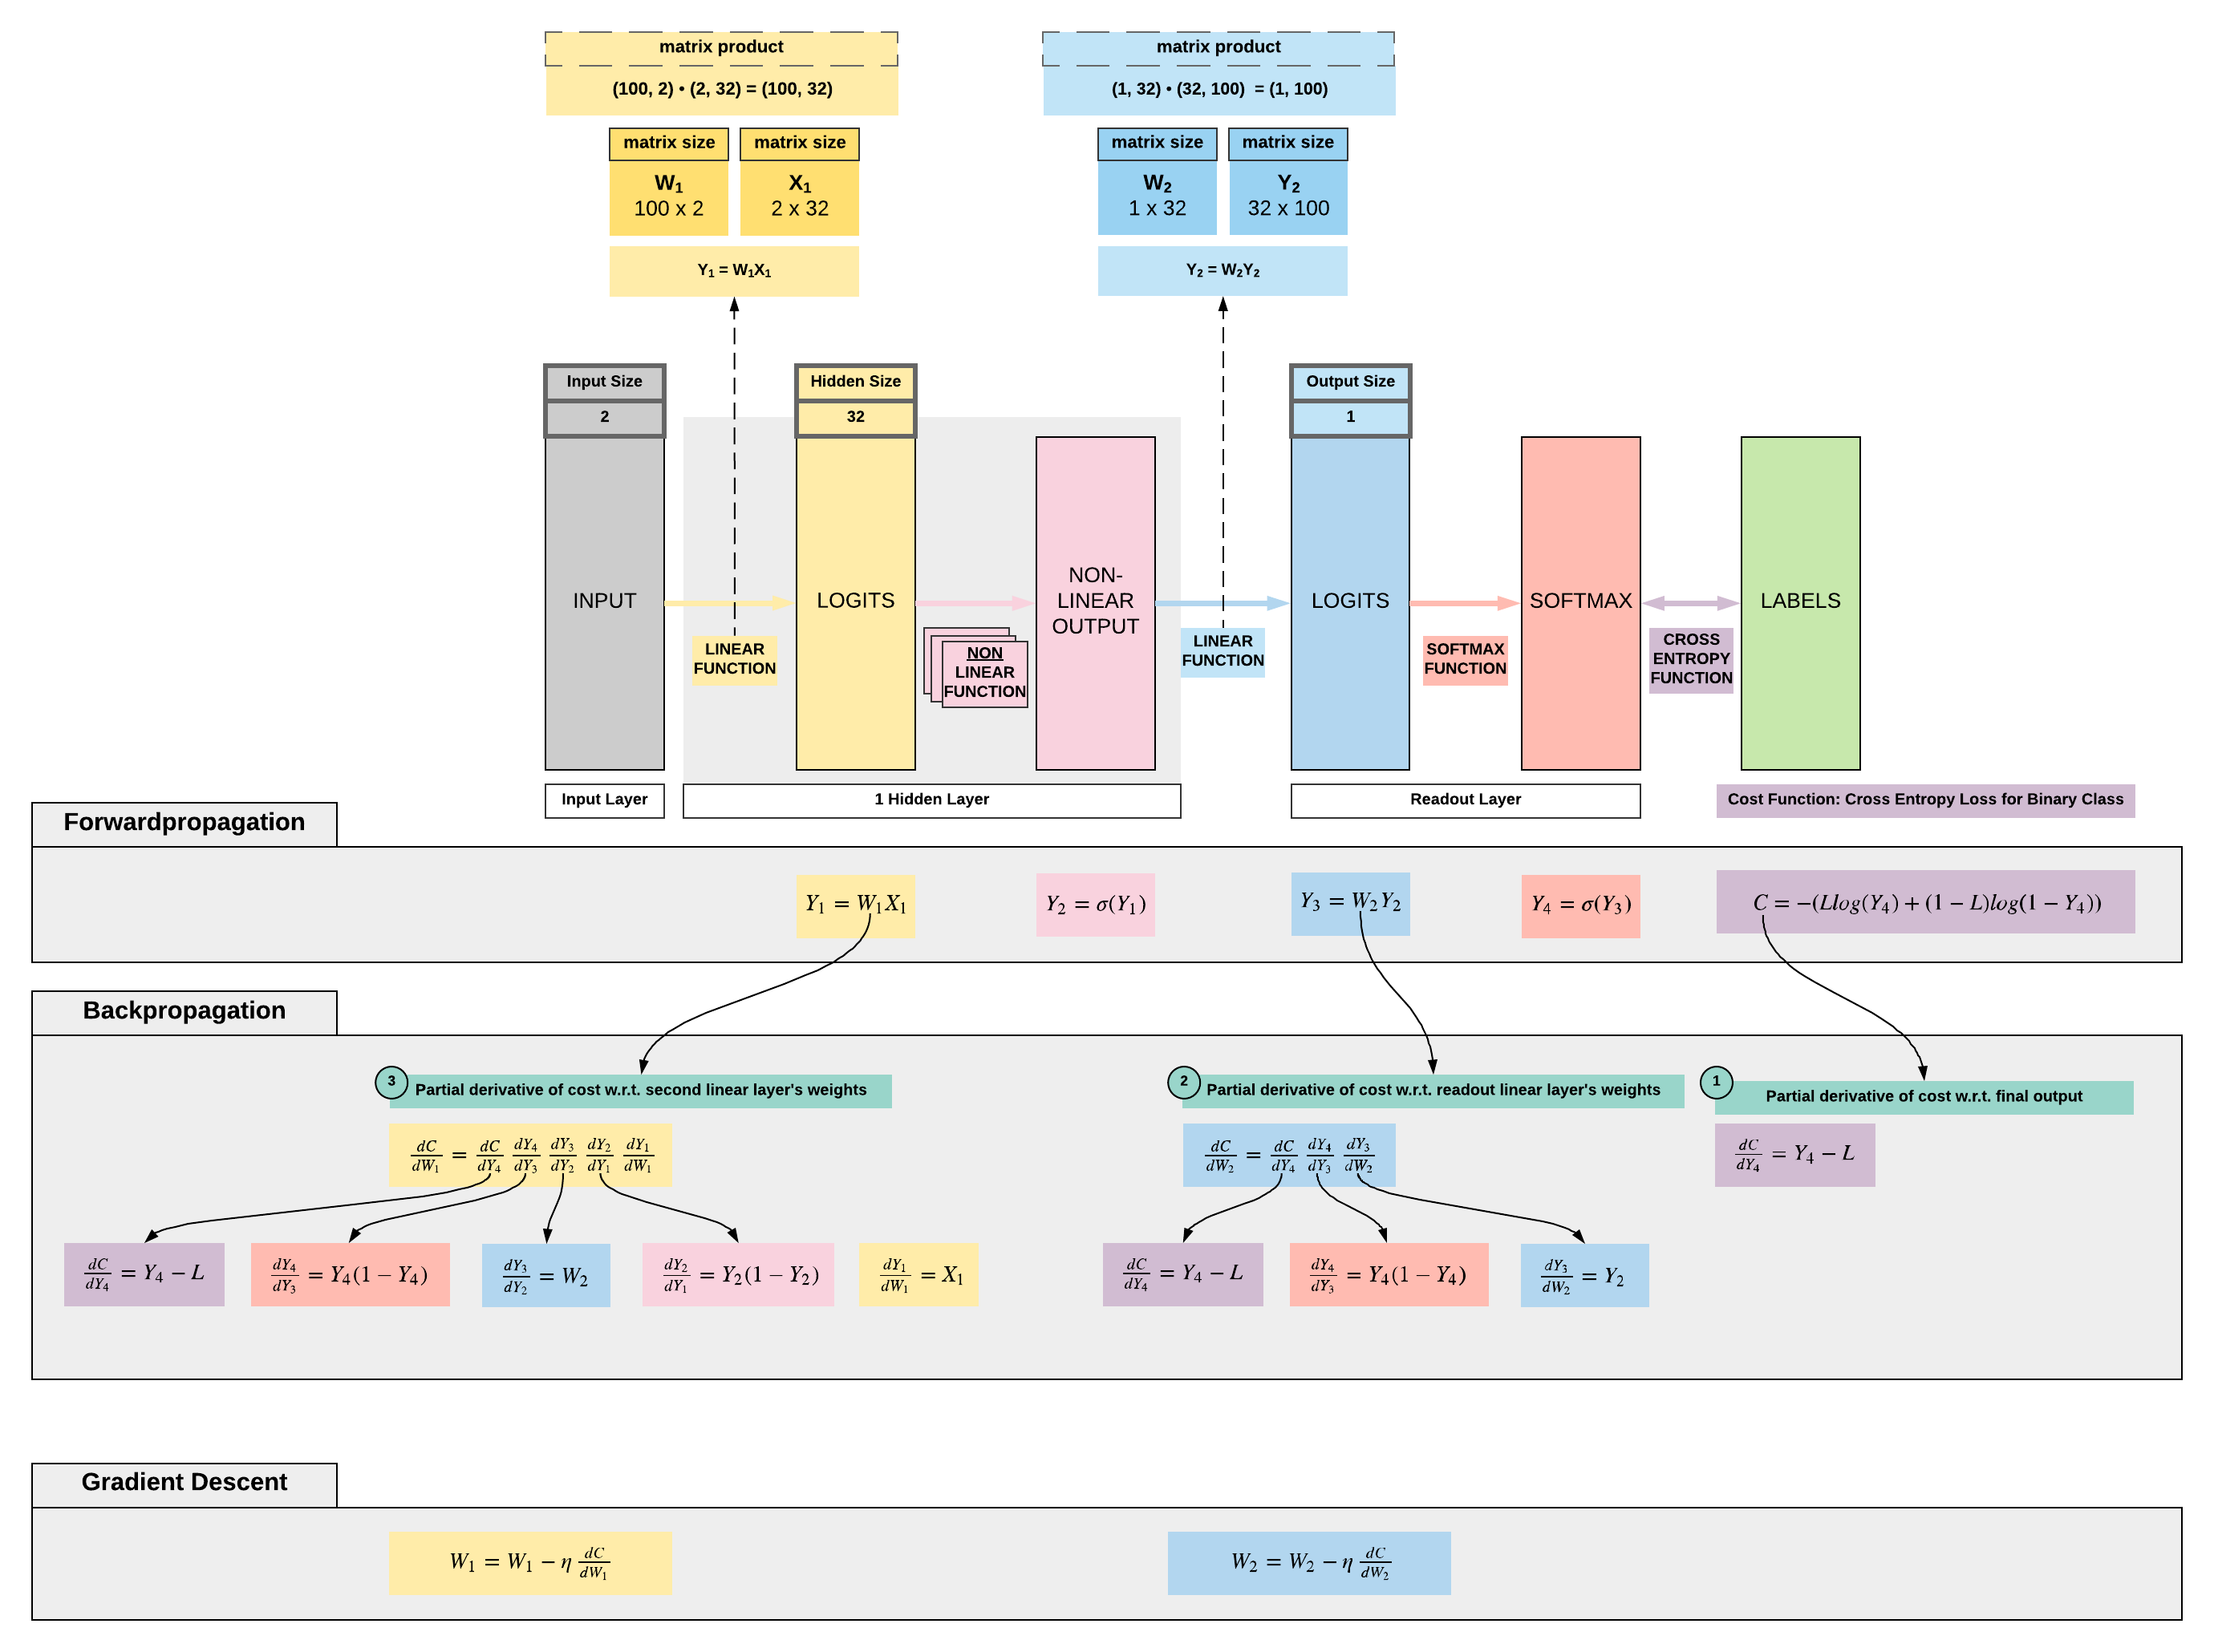

# Importing Necessary Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification # Example dataset generation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Forward Propagation

### Mathematical Equations for Forward Pass

As previously introduced, the forward pass involves two primary steps: a linear transformation and the application of an activation function. Let's delve deeper into the mathematical representation and the tensor shapes involved.

#### 1. Linear Transformation

The linear transformation combines the inputs from the previous layer with learnable weights and biases to produce a 'pre-activation' value. For a single layer, this is represented as:

$$ Z = WX + b $$

Where:
*   **$X$ (Inputs)**: This represents the input features to the current layer. If $X$ is from the input layer, it's the raw data. If it's from a hidden layer, it's the activated output of the previous layer.
    *   **Shape:** `(n_features, n_samples)` or `(n_samples, n_features)`. For consistency in matrix multiplication, we often use `(n_features, n_samples)`. Each column is a sample, each row is a feature.
*   **$W$ (Weights)**: These are the learnable parameters that determine the strength of the connection between the inputs and the neurons in the current layer. Each neuron in the current layer has a set of weights corresponding to each input feature.
    *   **Shape:** `(n_neurons_current_layer, n_features_previous_layer)`. The number of rows corresponds to the number of neurons in the current layer, and the number of columns corresponds to the number of features received from the previous layer.
*   **$b$ (Bias)**: This is another learnable parameter added to the weighted sum. It allows the activation function to be shifted, providing more flexibility to the model to fit the data.
    *   **Shape:** `(n_neurons_current_layer, 1)`. Each neuron in the current layer has its own bias term.
*   **$Z$ (Pre-activation Output)**: This is the linear combination before applying the activation function. It's the weighted sum of inputs plus the bias.
    *   **Shape:** `(n_neurons_current_layer, n_samples)`. The number of rows corresponds to the number of neurons in the current layer, and the number of columns is the number of samples being processed.

**Example of Matrix Multiplication:**
If `X` is `(3, 100)` (3 features, 100 samples) and `W` is `(5, 3)` (5 neurons in current layer, 3 features from previous layer), then `Z = WX` will be `(5, 100)`. The bias `b` of shape `(5, 1)` will be broadcasted across the 100 samples when added to `Z`.

#### 2. Activation Functions

After the linear transformation, an activation function is applied element-wise to introduce non-linearity into the network. This non-linearity is crucial for the network to learn complex patterns and make decisions that are not just linear combinations of its inputs.

Let $A$ be the activated output of a layer, then:

$$ A = \text{Activation}(Z) $$

Where:
*   **$A$ (Activated Output)**: The output of the activation function, which then serves as the input $X$ for the next layer.
    *   **Shape:** `(n_neurons_current_layer, n_samples)`. The shape remains the same as $Z$ because activation functions are applied element-wise.

Common activation functions include:

*   **Sigmoid Function:**
    $$ \sigma(z) = \frac{1}{1 + e^{-z}} $$
    *   **Purpose:** Squashes values between 0 and 1. Historically used in output layers for binary classification, but less common in hidden layers due to vanishing gradient issues.
    *   **Input/Output Shape:** `(Any shape)` -> `(Same shape)`

*   **Rectified Linear Unit (ReLU) Function:**
    $$ \text{ReLU}(z) = \max(0, z) $$
    *   **Purpose:** Outputs the input directly if it is positive, otherwise, it outputs zero. Popular in hidden layers for its computational efficiency and ability to mitigate vanishing gradients.
    *   **Input/Output Shape:** `(Any shape)` -> `(Same shape)`

These activated outputs $A$ then become the inputs $X$ for the subsequent layer, and the process of linear transformation and activation repeats until the final output layer is reached.

Now let us define Python functions for the sigmoid and ReLU activation functions, along with their derivatives.

In [2]:
def sigmoid(Z):
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(A):
    return A * (1 - A)

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def leaky_relu(Z, alpha=0.01):
    return np.where(Z > 0, Z, alpha * Z)

def leaky_relu_derivative(Z, alpha=0.01):
    return np.where(Z > 0, 1, alpha)

def tanh(Z):
    return np.tanh(Z)

def tanh_derivative(A):
    return 1 - np.square(A)

Z = np.array([[-2, -1, 0, 1, 2]])

print("Sigmoid:", sigmoid(Z))
print("ReLU:", relu(Z))
print("Leaky ReLU:", leaky_relu(Z))
print("Tanh:", tanh(Z))

Sigmoid: [[0.11920292 0.26894142 0.5        0.73105858 0.88079708]]
ReLU: [[0 0 0 1 2]]
Leaky ReLU: [[-0.02 -0.01  0.    1.    2.  ]]
Tanh: [[-0.96402758 -0.76159416  0.          0.76159416  0.96402758]]


Now that the activation functions are defined, the next step is to implement the `forward_pass` function, which computes the linear transformation ($Z = WX + b$) and then applies an activation function. This function will include comments to explicitly show tensor shapes.

In [3]:
def forward_pass(X, W, b, activation_fn):
    """
    Forward pass for one neural network layer.
    """

    # Linear Transformation
    Z = np.dot(W, X) + b

    # Activation
    A = activation_fn(Z)

    # Optional debugging experiment
    # print("X Shape:", X.shape)
    # print("W Shape:", W.shape)
    # print("b Shape:", b.shape)
    # print("Z Shape:", Z.shape)
    # print("A Shape:", A.shape)

    return A, Z

X_demo = np.random.randn(4, 5)
W_demo = np.random.randn(3, 4)      # 3 neurons
b_demo = np.random.randn(3, 1)

A_sigmoid, Z_sigmoid = forward_pass(
    X_demo, W_demo, b_demo, sigmoid
)

A_relu, Z_relu = forward_pass(
    X_demo, W_demo, b_demo, relu
)

A_tanh, Z_tanh = forward_pass(
    X_demo, W_demo, b_demo, tanh
)

print("Sigmoid Output Shape:", A_sigmoid.shape)
print("ReLU Output Shape:", A_relu.shape)
print("Tanh Output Shape:", A_tanh.shape)

Sigmoid Output Shape: (3, 5)
ReLU Output Shape: (3, 5)
Tanh Output Shape: (3, 5)


=== Hidden Layer ===
Input X Shape: (8, 200)
Weights Shape: (16, 8)
Bias Shape: (16, 1)
Z Shape: (16, 200)
A Shape: (16, 200)

Hidden Layer Statistics
Mean Activation: -0.0043512225729023515
Max Activation : 0.532781997020249
Min Activation : -0.5728805084606682

=== Output Layer ===
Input Shape: (16, 200)
Weights Shape: (1, 16)
Bias Shape: (1, 1)
Z Shape: (1, 200)
A Shape: (1, 200)

Output Statistics
Mean Probability: 0.4996336080703149
Max Probability : 0.5129550148674327
Min Probability : 0.48486289131369203


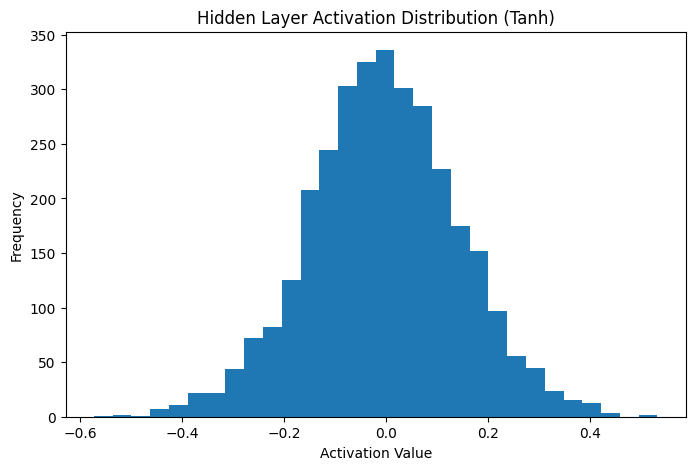

In [4]:
np.random.seed(123)  # changed seed

n_features_input = 8
n_samples_example = 200

X_example = np.random.randn(
    n_features_input,
    n_samples_example
)

# Hidden Layer
n_neurons_hidden = 16

W_hidden_example = (
    np.random.randn(
        n_neurons_hidden,
        n_features_input
    ) * 0.05
)

b_hidden_example = np.zeros(
    (n_neurons_hidden, 1)
)

A_hidden_example, Z_hidden_example = forward_pass(
    X_example,
    W_hidden_example,
    b_hidden_example,
    tanh
)

print("=== Hidden Layer ===")
print("Input X Shape:", X_example.shape)
print("Weights Shape:", W_hidden_example.shape)
print("Bias Shape:", b_hidden_example.shape)
print("Z Shape:", Z_hidden_example.shape)
print("A Shape:", A_hidden_example.shape)

print("\nHidden Layer Statistics")
print("Mean Activation:", np.mean(A_hidden_example))
print("Max Activation :", np.max(A_hidden_example))
print("Min Activation :", np.min(A_hidden_example))

n_neurons_output = 1

W_output_example = (
    np.random.randn(
        n_neurons_output,
        n_neurons_hidden
    ) * 0.05
)

b_output_example = np.zeros(
    (n_neurons_output, 1)
)

A_output_example, Z_output_example = forward_pass(
    A_hidden_example,
    W_output_example,
    b_output_example,
    sigmoid
)

print("\n=== Output Layer ===")
print("Input Shape:", A_hidden_example.shape)
print("Weights Shape:", W_output_example.shape)
print("Bias Shape:", b_output_example.shape)
print("Z Shape:", Z_output_example.shape)
print("A Shape:", A_output_example.shape)

print("\nOutput Statistics")
print("Mean Probability:", np.mean(A_output_example))
print("Max Probability :", np.max(A_output_example))
print("Min Probability :", np.min(A_output_example))

plt.figure(figsize=(8,5))
plt.hist(
    A_hidden_example.flatten(),
    bins=30
)
plt.title("Hidden Layer Activation Distribution (Tanh)")
plt.xlabel("Activation Value")
plt.ylabel("Frequency")
plt.show()

## Backward Propagation

Now let us understand mathematics behind backpropagation using the chain rule to calculate gradients for weights and biases. Implement the backward pass in Python, highlighting tensor shapes for all gradient calculations.


### Mathematical Equations for Backward Pass

Backward propagation is the algorithm used to effectively train neural networks by calculating the gradients of the loss function with respect to the network's weights and biases. It leverages the chain rule of calculus to efficiently compute these gradients, starting from the output layer and moving backward through the hidden layers.

Let $L$ denote the loss function, $m$ be the number of samples, $A^{[l]}$ be the activation of layer $l$, $Z^{[l]}$ be the pre-activation of layer $l$, $W^{[l]}$ be the weights of layer $l$, and $b^{[l]}$ be the biases of layer $l$.

#### 1. Loss Functions and Their Derivatives

To begin backpropagation, we first need to compute the gradient of the loss function with respect to the output layer's activation, $dA^{[L]}$ (where $L$ is the output layer).

*   **Mean Squared Error (MSE) for Regression:**
    *   Loss: $L = \frac{1}{2m} \sum_{i=1}^m (A^{[L](i)} - Y^{(i)})^2$
    *   Derivative w.r.t. output activation $A^{[L]}$: $dA^{[L]} = \frac{\partial L}{\partial A^{[L]}} = \frac{1}{m} (A^{[L]} - Y)$
    *   **Shapes:** $A^{[L]}$, $Y$, and $dA^{[L]}$ all have shape `(n_neurons_output_layer, n_samples)`.

*   **Binary Cross-Entropy Loss for Classification (with Sigmoid output):**
    *   Loss: $L = -\frac{1}{m} \sum_{i=1}^m [Y^{(i)} \log(A^{[L](i)}) + (1 - Y^{(i)}) \log(1 - A^{[L](i)})]$
    *   When combined with the sigmoid activation function for the output layer, the derivative with respect to the pre-activation $Z^{[L]}$ simplifies significantly, making it common to directly calculate $dZ^{[L]}$ for the output layer:
        *   $dZ^{[L]} = \frac{\partial L}{\partial Z^{[L]}} = \frac{1}{m} (A^{[L]} - Y)$
    *   **Shapes:** $A^{[L]}$, $Y$, and $dZ^{[L]}$ all have shape `(n_neurons_output_layer, n_samples)`.

#### 2. Propagating Error Backward (Chain Rule for a single layer)

For any hidden layer $l$ (or the output layer, using $dA^{[l]}$ as the starting point, or $dZ^{[L]}$ if using the simplified binary cross-entropy derivative), we apply the chain rule to calculate gradients for $Z^{[l]}$, $W^{[l]}$, $b^{[l]}$, and $A^{[l-1]}$ (which is the input to layer $l$).

Given the forward pass equations for layer $l$:
$$ Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]} \\
 A^{[l]} = \text{Activation}(Z^{[l]}) $$

We derive the gradients:

*   **Gradient of Loss w.r.t. Pre-activation ($dZ^{[l]}$):**
    *   This is the error signal for the current layer's linear output before activation.
    *   Formula: $dZ^{[l]} = dA^{[l]} \cdot \text{activation_derivative}(Z^{[l]})$ (element-wise multiplication, $\cdot$ for Hadamard product).
    *   **Shapes:**
        *   $dA^{[l]}$: `(n_neurons_current_layer, n_samples)`
        *   $\text{activation_derivative}(Z^{[l]})$: `(n_neurons_current_layer, n_samples)`
        *   $dZ^{[l]}$: `(n_neurons_current_layer, n_samples)`

*   **Gradient of Loss w.r.t. Weights ($dW^{[l]}$):**
    *   Indicates how much each weight contributes to the total error.
    *   Formula: $dW^{[l]} = \frac{1}{m} dZ^{[l]} (A^{[l-1]})^T$ (matrix multiplication).
    *   **Shapes:**
        *   $dZ^{[l]}$: `(n_neurons_current_layer, n_samples)`
        *   $(A^{[l-1]})^T$: `(n_samples, n_features_previous_layer)`
        *   $dW^{[l]}$: `(n_neurons_current_layer, n_features_previous_layer)` (Matches $W^{[l]}$ shape)

*   **Gradient of Loss w.r.t. Biases ($db^{[l]}$):**
    *   Indicates how much each bias contributes to the total error.
    *   Formula: $db^{[l]} = \frac{1}{m} \sum_{samples} dZ^{[l]}$ (sum $dZ^{[l]}$ across the sample dimension).
    *   **Shapes:**
        *   $dZ^{[l]}$: `(n_neurons_current_layer, n_samples)`
        *   $db^{[l]}$: `(n_neurons_current_layer, 1)` (Matches $b^{[l]}$ shape)

*   **Gradient of Loss w.r.t. Previous Layer's Activation ($dA^{[l-1]}$):**
    *   This is the error signal passed back to the previous layer, which will then use it as $dA$ for its own backpropagation.
    *   Formula: $dA^{[l-1]} = (W^{[l]})^T dZ^{[l]}$ (matrix multiplication).
    *   **Shapes:**
        *   $(W^{[l]})^T$: `(n_features_previous_layer, n_neurons_current_layer)`
        *   $dZ^{[l]}$: `(n_neurons_current_layer, n_samples)`
        *   $dA^{[l-1]}$: `(n_features_previous_layer, n_samples)` (Matches $A^{[l-1]}$ shape)

These gradients are then used by an optimizer (like Gradient Descent) to update the weights and biases, iteratively improving the network's performance.

The next step is to demonstrate the `backward_pass` function using the previously generated forward pass outputs and hypothetical target labels. This involves calculating the initial gradient for the output layer, then applying `backward_pass` to the output layer, and finally to the hidden layer.

=== Output Layer Backprop ===
dW Shape: (1, 16)
db Shape: (1, 1)
dA Hidden Shape: (16, 200)

=== Hidden Layer Backprop ===
dW Shape: (16, 8)
db Shape: (16, 1)
dA Input Shape: (8, 200)

Gradient Statistics
Mean dW Hidden : -3.4228010433546723e-06
Max dW Hidden  : 0.00010099040293451135
Min dW Hidden  : -0.00012066001500011018


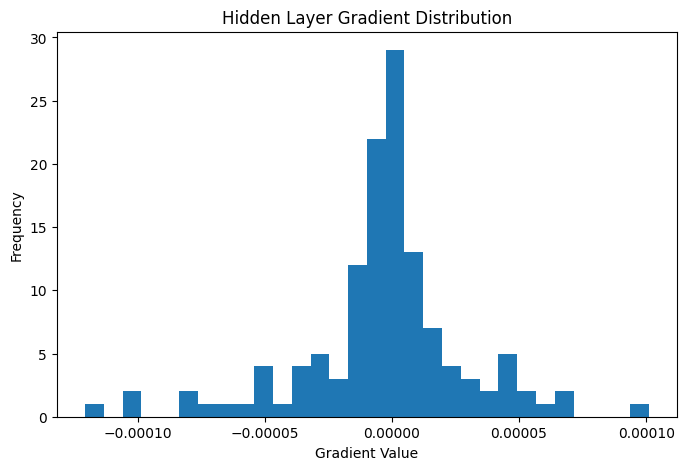

In [5]:
def backward_pass(dA, Z, A_prev, W, activation_derivative_fn, m):
    """
    Backward pass for one neural network layer.
    """

    # Gradient through activation
    dZ = dA * activation_derivative_fn(Z)

    # Weight gradients
    dW = (1 / m) * np.dot(dZ, A_prev.T)

    # Bias gradients
    db = (1 / m) * np.sum(
        dZ,
        axis=1,
        keepdims=True
    )

    # Propagate gradient backward
    dA_prev = np.dot(W.T, dZ)

    return dA_prev, dW, db

m = n_samples_example

# Random binary targets
Y_example = (
    np.random.rand(1, m) > 0.5
).astype(int)

# Output layer gradient
dA_output = A_output_example - Y_example

# Backward pass through output layer
dA_hidden, dW_output, db_output = backward_pass(
    dA_output,
    Z_output_example,
    A_hidden_example,
    W_output_example,
    sigmoid_derivative,
    m
)

print("=== Output Layer Backprop ===")
print("dW Shape:", dW_output.shape)
print("db Shape:", db_output.shape)
print("dA Hidden Shape:", dA_hidden.shape)

# Backward pass through hidden layer
dA_input, dW_hidden, db_hidden = backward_pass(
    dA_hidden,
    Z_hidden_example,
    X_example,
    W_hidden_example,
    tanh_derivative,
    m
)

print("\n=== Hidden Layer Backprop ===")
print("dW Shape:", dW_hidden.shape)
print("db Shape:", db_hidden.shape)
print("dA Input Shape:", dA_input.shape)

print("\nGradient Statistics")
print("Mean dW Hidden :", np.mean(dW_hidden))
print("Max dW Hidden  :", np.max(dW_hidden))
print("Min dW Hidden  :", np.min(dW_hidden))

# Visualize gradient distribution
plt.figure(figsize=(8,5))
plt.hist(
    dW_hidden.flatten(),
    bins=30
)
plt.title("Hidden Layer Gradient Distribution")
plt.xlabel("Gradient Value")
plt.ylabel("Frequency")
plt.show()

=== Output Layer Backpropagation ===
Target Shape: (1, 200)
dW Output Shape: (1, 16)
db Output Shape: (1, 1)
dA Hidden Shape: (16, 200)

=== Hidden Layer Backpropagation ===
dW Hidden Shape: (16, 8)
db Hidden Shape: (16, 1)
dA Input Shape: (8, 200)

Gradient Statistics
Mean dW Hidden: -0.00017749019970755476
Std dW Hidden : 0.00234702240048968
Max dW Hidden : 0.006889857565974275
Min dW Hidden : -0.008061594855334642


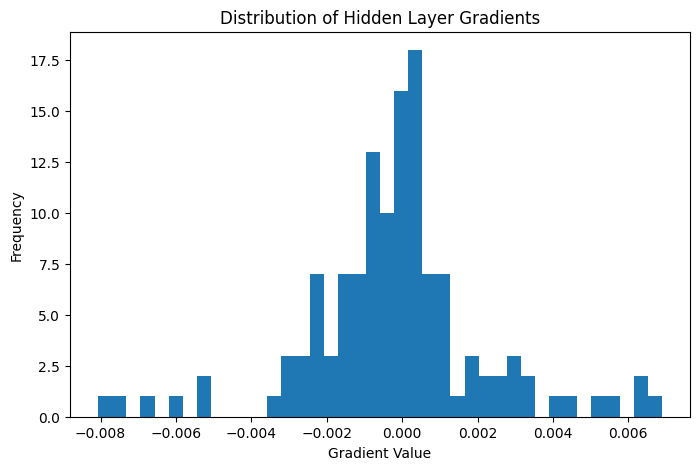

In [6]:

np.random.seed(123)

# Random targets
Y_example = np.random.randint(
    0, 2,
    size=(n_neurons_output, n_samples_example)
)

m_example = n_samples_example

print("=== Output Layer Backpropagation ===")
print("Target Shape:", Y_example.shape)

# BCE + Sigmoid simplified gradient
dZ_output_layer = (A_output_example - Y_example)

# Output gradients
dW_output_computed = (
    1 / m_example
) * np.dot(
    dZ_output_layer,
    A_hidden_example.T
)

db_output_computed = (
    1 / m_example
) * np.sum(
    dZ_output_layer,
    axis=1,
    keepdims=True
)

dA_hidden = np.dot(
    W_output_example.T,
    dZ_output_layer
)

print("dW Output Shape:", dW_output_computed.shape)
print("db Output Shape:", db_output_computed.shape)
print("dA Hidden Shape:", dA_hidden.shape)

# Hidden Layer Backprop
dA_input_layer, dW_hidden_computed, db_hidden_computed = backward_pass(
    dA=dA_hidden,
    Z=Z_hidden_example,
    A_prev=X_example,
    W=W_hidden_example,
    activation_derivative_fn=tanh_derivative,   # changed from ReLU
    m=m_example
)

print("\n=== Hidden Layer Backpropagation ===")
print("dW Hidden Shape:", dW_hidden_computed.shape)
print("db Hidden Shape:", db_hidden_computed.shape)
print("dA Input Shape:", dA_input_layer.shape)

print("\nGradient Statistics")
print("Mean dW Hidden:", np.mean(dW_hidden_computed))
print("Std dW Hidden :", np.std(dW_hidden_computed))
print("Max dW Hidden :", np.max(dW_hidden_computed))
print("Min dW Hidden :", np.min(dW_hidden_computed))

plt.figure(figsize=(8,5))
plt.hist(
    dW_hidden_computed.flatten(),
    bins=40
)
plt.title("Distribution of Hidden Layer Gradients")
plt.xlabel("Gradient Value")
plt.ylabel("Frequency")
plt.show()

## Synthetic Data Demonstration

Now let us generate synthetic data for a simple task (e.g., binary classification). Then we will integrate the forward and backward propagation implementations into a training loop, optimize weights and biases, and visualize the model's performance (e.g., decision boundary) and the training loss curve.


The first step now is to generate synthetic data, split it, standardize it, reshape it, and initialize the neural network parameters. This will set up the necessary data and model architecture for the training loop.


Original X Shape: (400, 2)
Original Y Shape: (1, 400)

Training Shape: (2, 300)
Testing Shape : (2, 100)

Initialized Parameters
W1 Shape: (8, 2)
b1 Shape: (8, 1)
W2 Shape: (1, 8)
b2 Shape: (1, 1)


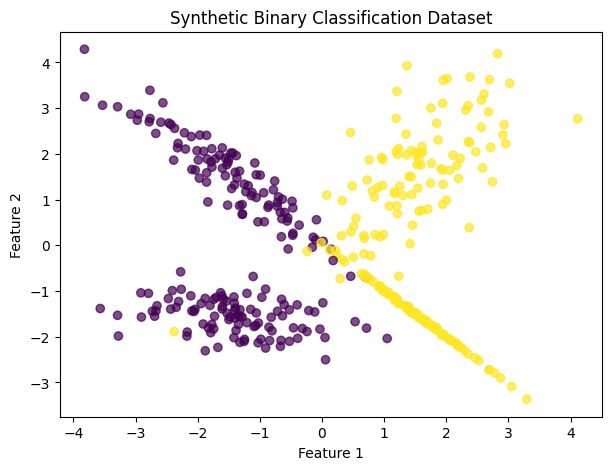

In [7]:
np.random.seed(123)

# Generate a slightly harder dataset
X, Y = make_classification(
    n_samples=400,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    class_sep=1.5,
    random_state=123
)

Y = Y.reshape(1, -1)

print("Original X Shape:", X.shape)
print("Original Y Shape:", Y.shape)

# Train/Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y.T,
    test_size=0.25,
    random_state=123,
    stratify=Y.T
)

Y_train = Y_train.T
Y_test = Y_test.T

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for NN
X_train_nn = X_train_scaled.T
X_test_nn = X_test_scaled.T

print("\nTraining Shape:", X_train_nn.shape)
print("Testing Shape :", X_test_nn.shape)


n_x = X_train_nn.shape[0]
n_h = 8
n_y = Y_train.shape[0]

W1 = np.random.randn(
    n_h,
    n_x
) * np.sqrt(1 / n_x)

b1 = np.zeros((n_h, 1))

W2 = np.random.randn(
    n_y,
    n_h
) * np.sqrt(1 / n_h)

b2 = np.zeros((n_y, 1))

print("\nInitialized Parameters")
print("W1 Shape:", W1.shape)
print("b1 Shape:", b1.shape)
print("W2 Shape:", W2.shape)
print("b2 Shape:", b2.shape)

# Visualize Dataset
plt.figure(figsize=(7,5))
plt.scatter(
    X[:,0],
    X[:,1],
    c=Y.flatten(),
    alpha=0.7
)
plt.title("Synthetic Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Now let us implement the training loop as described earlier as well. This involves defining hyperparameters, storing loss and accuracy history, performing forward and backward passes, calculating loss and accuracy, and updating parameters over several epochs.

In [8]:
np.random.seed(123) # for reproducibility in training loop

# 6. Implement a training loop

# Define hyperparameters
epochs = 2000
learning_rate = 0.03
m = X_train_nn.shape[1] # Number of training samples

# Create empty lists to store loss and accuracy history
loss_history = []
accuracy_history = []

print(f"\nStarting training with {epochs} epochs and learning rate {learning_rate}...")

# For each epoch:
for i in range(epochs):

    # Forward Pass

    # Layer 1: Hidden Layer (ReLU activation)
    # Input: X_train_nn (n_x, m)
    # W1: (n_h, n_x), b1: (n_h, 1)
    A1, Z1 = forward_pass(X_train_nn, W1, b1, tanh)
    # A1, Z1 shapes: (n_h, m)

    # Layer 2: Output Layer (Sigmoid activation)
    # Input: A1 (n_h, m)
    # W2: (n_y, n_h), b2: (n_y, 1)
    A2, Z2 = forward_pass(A1, W2, b2, sigmoid)
    # A2, Z2 shapes: (n_y, m)

    # Calculate Loss (Binary Cross-Entropy)
    # Ensure no log(0) issues
    epsilon = 1e-8
    loss = -np.mean(Y_train * np.log(A2 + epsilon)+(1 - Y_train) * np.log(1 - A2 + epsilon))
    loss_history.append(loss)

    # Backward Pass

    # Calculate initial dZ2 for the output layer
    # This simplifies to (A2 - Y_train) / m for BCE with Sigmoid
    dZ2 = (A2 - Y_train)
    dW2 = (1 / m) * np.dot(dZ2,A1.T)

    db2 = (1 / m) * np.sum(dZ2,axis=1,keepdims=True)

    dA1 = np.dot(W2.T,dZ2)
    # dZ2 shape: (n_y, m)

    # Backward pass for the hidden layer
    # dA_prev_L0 (gradient for X_train_nn), dW1, db1
    dA0, dW1, db1 = backward_pass(
        dA=dA1, # dA1 is the gradient from the subsequent layer
        Z=Z1,
        A_prev=X_train_nn,
        W=W1,
        activation_derivative_fn=tanh_derivative,
        m=m
    )

    # Update Parameters
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    # Calculate Training Accuracy
    predictions = (A2 > 0.5).astype(int)
    accuracy = np.mean(predictions == Y_train)
    accuracy_history.append(accuracy)

    if (i + 1) % 100 == 0:
        print(f"Epoch {i+1}/{epochs} - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

print("Training complete.")
print(f"Final Loss: {loss_history[-1]:.4f}")
print(f"Final Accuracy: {accuracy_history[-1]:.4f}")



Starting training with 2000 epochs and learning rate 0.03...
Epoch 100/2000 - Loss: 0.3545, Accuracy: 0.9533
Epoch 200/2000 - Loss: 0.2255, Accuracy: 0.9600
Epoch 300/2000 - Loss: 0.1738, Accuracy: 0.9667
Epoch 400/2000 - Loss: 0.1445, Accuracy: 0.9767
Epoch 500/2000 - Loss: 0.1237, Accuracy: 0.9767
Epoch 600/2000 - Loss: 0.1090, Accuracy: 0.9733
Epoch 700/2000 - Loss: 0.1011, Accuracy: 0.9667
Epoch 800/2000 - Loss: 0.0934, Accuracy: 0.9700
Epoch 900/2000 - Loss: 0.0895, Accuracy: 0.9733
Epoch 1000/2000 - Loss: 0.0885, Accuracy: 0.9733
Epoch 1100/2000 - Loss: 0.0874, Accuracy: 0.9800
Epoch 1200/2000 - Loss: 0.0848, Accuracy: 0.9800
Epoch 1300/2000 - Loss: nan, Accuracy: 0.4967


/tmp/ipykernel_3769/3366118279.py:24: RuntimeWarning: overflow encountered in square
  return 1 - np.square(A)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Epoch 1400/2000 - Loss: nan, Accuracy: 0.4967
Epoch 1500/2000 - Loss: nan, Accuracy: 0.4967
Epoch 1600/2000 - Loss: nan, Accuracy: 0.4967
Epoch 1700/2000 - Loss: nan, Accuracy: 0.4967
Epoch 1800/2000 - Loss: nan, Accuracy: 0.4967
Epoch 1900/2000 - Loss: nan, Accuracy: 0.4967
Epoch 2000/2000 - Loss: nan, Accuracy: 0.4967
Training complete.
Final Loss: nan
Final Accuracy: 0.4967


Now let us plot the `loss_history` against the epochs to visualize the training loss curve.

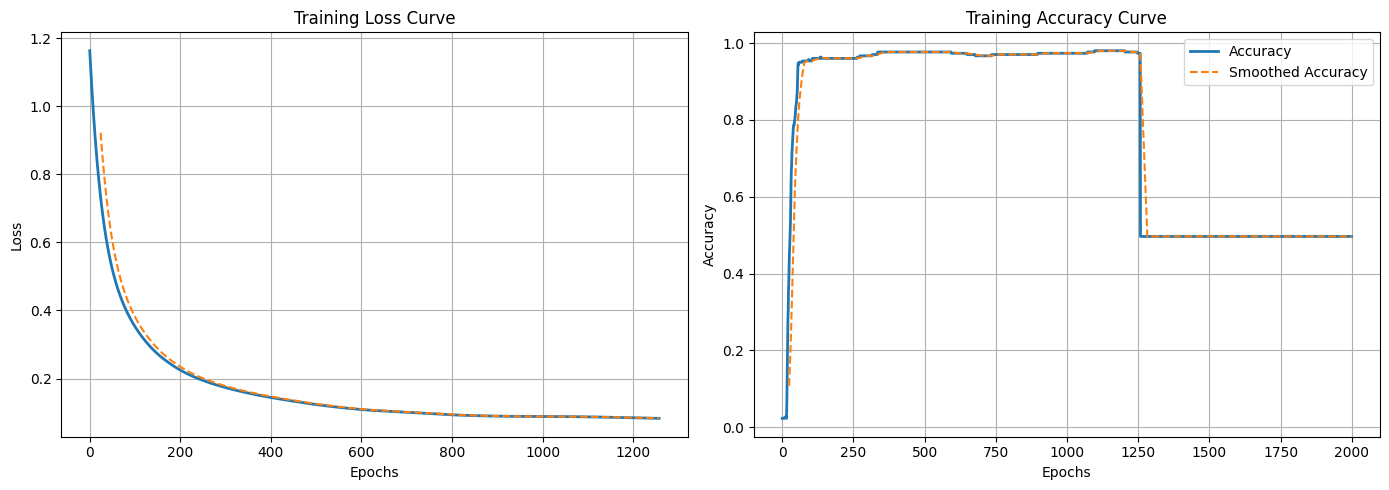

Initial Loss     : 1.1635548706457401
Final Loss       : nan
Best Accuracy    : 0.98
Final Accuracy   : 0.49666666666666665


In [9]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history,label="Loss",linewidth=2)

window = 25
smooth_loss = np.convolve(loss_history,np.ones(window)/window,mode='valid')
plt.plot(range(window-1, len(loss_history)),smooth_loss,'--',label="Smoothed Loss")
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracy_history,label="Accuracy",linewidth=2)
smooth_acc = np.convolve(accuracy_history,np.ones(window)/window,mode='valid')
plt.plot(range(window-1, len(accuracy_history)),smooth_acc,'--',label="Smoothed Accuracy")
plt.title('Training Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Initial Loss     :", loss_history[0])
print("Final Loss       :", loss_history[-1])
print("Best Accuracy    :", max(accuracy_history))
print("Final Accuracy   :", accuracy_history[-1])

Now let us visualize the model's performance by plotting the decision boundary. To do this, we need a prediction function that utilizes the trained weights and biases. This function will take the input data and perform a forward pass to output predictions.

In [10]:
def predict(X, W1, b1, W2, b2):
    """
    Performs a forward pass to get predictions from the trained neural network.

    Args:
        X (np.ndarray): Input data. Shape: (n_features, n_samples)
        W1 (np.ndarray): Weights for the hidden layer.
        b1 (np.ndarray): Biases for the hidden layer.
        W2 (np.ndarray): Weights for the output layer.
        b2 (np.ndarray): Biases for the output layer.

    Returns:
        np.ndarray: Predicted class labels (0 or 1). Shape: (1, n_samples)
    """
    # Layer 1: Hidden Layer (ReLU activation)
    A1, _ = forward_pass(X, W1, b1, tanh)

    # Layer 2: Output Layer (Sigmoid activation)
    A2, _ = forward_pass(A1, W2, b2, sigmoid)

    predictions = (A2 > 0.6).astype(int)
    return predictions

Now let us visualize the decision boundary of the trained model. This involves creating a meshgrid, using the predict function to classify each point, and then plotting the decision boundary along with the original data points.


Plotting decision boundary...


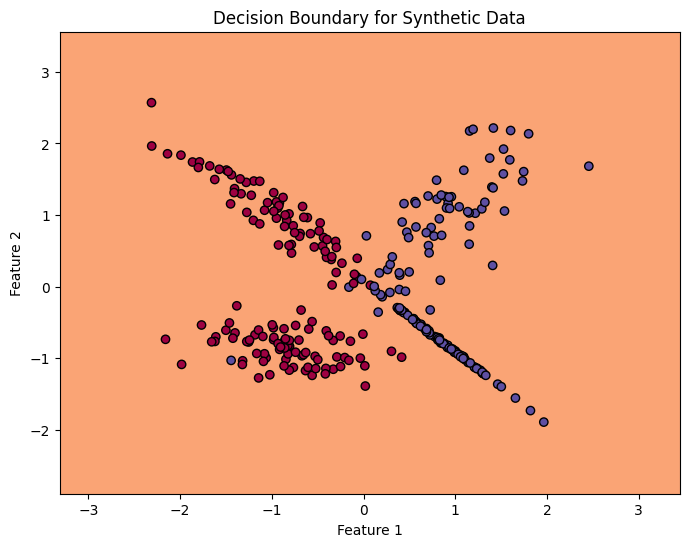

Test Accuracy: 0.5000
Synthetic data demonstration complete.


In [11]:
def plot_decision_boundary(X, Y, W1, b1, W2, b2):
    """
    Plots the decision boundary created by the neural network.
    """
    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = predict(np.c_[xx.ravel(), yy.ravel()].T, W1, b1, W2, b2)
    Z = Z.reshape(xx.shape)

    # Plot the contour and the training examples
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[0, :], X[1, :], c=Y.ravel(), cmap=plt.cm.Spectral, edgecolors='k')
    plt.title('Decision Boundary for Synthetic Data')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Plot the decision boundary for the training set
print("\nPlotting decision boundary...")
plot_decision_boundary(X_train_nn, Y_train, W1, b1, W2, b2)

# Evaluate the model on the test set
predictions_test = predict(X_test_nn, W1, b1, W2, b2)
test_accuracy = np.mean(predictions_test == Y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("Synthetic data demonstration complete.")

## Real Data Application

Now let us import a real-world dataset from scikit-learn (e.g., Iris or digits dataset). We then preprocess the data as needed, adapt the neural network and training loop, and demonstrate the training process. We will also visualize the loss curve and evaluate the model's performance.

The first step is to load the Breast Cancer dataset from sklearn.datasets and separate it into features (X) and target (y).

In [12]:
from sklearn.datasets import load_breast_cancer

# 1. Load a real-world dataset for binary classification
data = load_breast_cancer()
X_real = data.data
Y_real = data.target

print(f"Features (X_real) shape: {X_real.shape}")
print(f"Target (Y_real) shape: {Y_real.shape}")

Features (X_real) shape: (569, 30)
Target (Y_real) shape: (569,)


The next step is to reshape the target variable Y_real to (1, n_samples) for consistency with the neural network's expected output format.

In [13]:
Y_real = Y_real.reshape(1, -1)

print(f"Reshaped Y_real shape: {Y_real.shape}")

Reshaped Y_real shape: (1, 569)


The next step is to split the dataset into training and testing sets using train_test_split, ensuring stratification and a random_state for reproducibility.

In [14]:
X_train_real, X_test_real, Y_train_real, Y_test_real = train_test_split(X_real,Y_real.T,test_size=0.25,random_state=123, stratify=Y_real.T)
Y_train_real = Y_train_real.T
Y_test_real = Y_test_real.T

print("X_train_real Shape :", X_train_real.shape)
print("Y_train_real Shape :", Y_train_real.shape)
print("X_test_real Shape  :", X_test_real.shape)
print("Y_test_real Shape  :", Y_test_real.shape)

print("\nTraining Class Distribution")
print("Class 0 :", np.sum(Y_train_real == 0))
print("Class 1 :", np.sum(Y_train_real == 1))

print("\nTesting Class Distribution")
print("Class 0 :", np.sum(Y_test_real == 0))
print("Class 1 :", np.sum(Y_test_real == 1))

# Percentage check
train_class1_pct = np.mean(Y_train_real) * 100
test_class1_pct = np.mean(Y_test_real) * 100

print("\nClass 1 Percentage")
print(f"Training : {train_class1_pct:.2f}%")
print(f"Testing  : {test_class1_pct:.2f}%")

# Sample inspection
print("\nFirst Training Label Batch:")


X_train_real Shape : (426, 30)
Y_train_real Shape : (1, 426)
X_test_real Shape  : (143, 30)
Y_test_real Shape  : (1, 143)

Training Class Distribution
Class 0 : 159
Class 1 : 267

Testing Class Distribution
Class 0 : 53
Class 1 : 90

Class 1 Percentage
Training : 62.68%
Testing  : 62.94%

First Training Label Batch:


Now let us standardize the features (X_train_real and X_test_real) using StandardScaler.

In [15]:
scaler_real = StandardScaler()
X_train_real_scaled = scaler_real.fit_transform(X_train_real)
X_test_real_scaled = scaler_real.transform(X_test_real)

print(f"X_train_real_scaled shape: {X_train_real_scaled.shape}")
print(f"X_test_real_scaled shape: {X_test_real_scaled.shape}")

X_train_real_scaled shape: (426, 30)
X_test_real_scaled shape: (143, 30)


In [16]:
X_train_real_nn = X_train_real_scaled.T
X_test_real_nn = X_test_real_scaled.T

print(f"Reshaped X_train_real_nn shape: {X_train_real_nn.shape}")
print(f"Reshaped X_test_real_nn shape: {X_test_real_nn.shape}")

Reshaped X_train_real_nn shape: (30, 426)
Reshaped X_test_real_nn shape: (30, 143)


The next step is to adapt the neural network parameters based on the new input features and output neurons of the real dataset. This involves re-initializing W1, b1, W2, and b2 with the correct shapes derived from `X_train_real_nn` and `Y_train_real`.

In [17]:
np.random.seed(123)
n_x_real = X_train_real_nn.shape[0]
n_h_real = 8
n_y_real = Y_train_real.shape[0]

W1_real = np.random.randn(n_h_real,n_x_real) * np.sqrt(1 / n_x_real)
b1_real = np.zeros((n_h_real, 1))

W2_real = np.random.randn(n_y_real,n_h_real) * np.sqrt(1 / n_h_real)

b2_real = np.zeros((n_y_real, 1))

print("\nInitialized Parameters for Real Dataset")
print("W1_real Shape :", W1_real.shape)
print("b1_real Shape :", b1_real.shape)
print("W2_real Shape :", W2_real.shape)
print("b2_real Shape :", b2_real.shape)

print("\nWeight Statistics")

print("W1 Mean :", np.mean(W1_real))
print("W1 Std  :", np.std(W1_real))

print("W2 Mean :", np.mean(W2_real))
print("W2 Std  :", np.std(W2_real))

print("\nWeight Ranges")
print("W1 Min :", np.min(W1_real))
print("W1 Max :", np.max(W1_real))

print("W2 Min :", np.min(W2_real))
print("W2 Max :", np.max(W2_real))


total_params = (W1_real.size +b1_real.size +W2_real.size +b2_real.size)

print("\nTotal Trainable Parameters :", total_params)


Initialized Parameters for Real Dataset
W1_real Shape : (8, 30)
b1_real Shape : (8, 1)
W2_real Shape : (1, 8)
b2_real Shape : (1, 1)

Weight Statistics
W1 Mean : -0.0018968367278185078
W1 Std  : 0.18638039154970049
W2 Mean : -0.06889374448691749
W2 Std  : 0.31107871878542

Weight Ranges
W1 Min : -0.5899072374591467
W1 Max : 0.47438322407322203
W2 Min : -0.7610213555017646
W2 Max : 0.22291118090818587

Total Trainable Parameters : 257


In [18]:
np.random.seed(123)

epochs_real = 3000
learning_rate_real = 0.01
m_real = X_train_real_nn.shape[1]
loss_history_real = []
accuracy_history_real = []
print("\nHyperparameters for Real Dataset")
print("Epochs               :", epochs_real)
print("Learning Rate        :", learning_rate_real)
print("Training Samples     :", m_real)
batch_size = 32
steps_per_epoch = int(np.ceil(m_real / batch_size))

print("Batch Size           :", batch_size)
print("Steps per Epoch      :", steps_per_epoch)
lr_decay = 0.995

print("Learning Rate Decay  :", lr_decay)
patience = 100

print("Early Stopping Patience :", patience)
total_params = (W1_real.size +b1_real.size +W2_real.size +b2_real.size)
print("Total Parameters     :", total_params)

print("\nHistory Lists Initialized")
print("Loss History Length      :", len(loss_history_real))
print("Accuracy History Length  :", len(accuracy_history_real))


Hyperparameters for Real Dataset
Epochs               : 3000
Learning Rate        : 0.01
Training Samples     : 426
Batch Size           : 32
Steps per Epoch      : 14
Learning Rate Decay  : 0.995
Early Stopping Patience : 100
Total Parameters     : 257

History Lists Initialized
Loss History Length      : 0
Accuracy History Length  : 0


The next step is to implement the training loop for the real dataset. This involves performing forward and backward passes, calculating binary cross-entropy loss, performing backward pass, and updating parameters for each epoch. It also includes storing loss and accuracy values.

In [19]:
np.random.seed(123)
print(f"\nStarting training for real data with "f"{epochs_real} epochs and "f"learning rate {learning_rate_real}...")
best_accuracy = 0
best_loss = float("inf")
for i in range(epochs_real):

    A1_real, Z1_real = forward_pass(X_train_real_nn,W1_real,b1_real,tanh)

    # Output Layer
    A2_real, Z2_real = forward_pass(A1_real,W2_real,b2_real,sigmoid)
    # BCE Loss
    epsilon = 1e-8

    loss_real = -np.mean(Y_train_real * np.log(A2_real + epsilon)+(1 - Y_train_real) *np.log(1 - A2_real + epsilon))
    loss_history_real.append(loss_real)

    # Backpropagation
    dZ2_real = A2_real - Y_train_real
    dW2_real = (np.dot(dZ2_real, A1_real.T)/ m_real)

    db2_real = (np.sum(dZ2_real,axis=1,keepdims=True)/ m_real)

    dA1_real = np.dot(W2_real.T,dZ2_real)

    # Hidden Layer Backward
    dA0_real, dW1_real, db1_real = backward_pass(
        dA=dA1_real,
        Z=Z1_real,
        A_prev=X_train_real_nn,
        W=W1_real,
        activation_derivative_fn=tanh_derivative,
        m=m_real
    )
    current_lr = (
        learning_rate_real *
        (0.995 ** (i // 100))
    )

    W1_real -= current_lr * dW1_real
    b1_real -= current_lr * db1_real

    W2_real -= current_lr * dW2_real
    b2_real -= current_lr * db2_real

    # Accuracy

    predictions_real = (
        A2_real > 0.5
    ).astype(int)

    accuracy_real = np.mean(
        predictions_real == Y_train_real
    )

    accuracy_history_real.append(
        accuracy_real
    )

    # Track best values

    best_accuracy = max(
        best_accuracy,
        accuracy_real
    )

    best_loss = min(
        best_loss,
        loss_real
    )

    if (i + 1) % 200 == 0:
        print(
            f"Epoch {i+1}/{epochs_real} | "
            f"Loss: {loss_real:.4f} | "
            f"Accuracy: {accuracy_real:.4f} | "
            f"LR: {current_lr:.6f}"
        )

print("\nTraining Complete")
print("Best Accuracy :", best_accuracy)
print("Best Loss     :", best_loss)
print("Final Loss    :", loss_history_real[-1])
print("Final Accuracy:", accuracy_history_real[-1])


Starting training for real data with 3000 epochs and learning rate 0.01...


/tmp/ipykernel_3769/3366118279.py:24: RuntimeWarning: overflow encountered in square
  return 1 - np.square(A)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Epoch 200/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009950
Epoch 400/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009851
Epoch 600/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009752
Epoch 800/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009655
Epoch 1000/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009559
Epoch 1200/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009464
Epoch 1400/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009369
Epoch 1600/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009276
Epoch 1800/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009183
Epoch 2000/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009092
Epoch 2200/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.009001
Epoch 2400/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.008911
Epoch 2600/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.008822
Epoch 2800/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.008734
Epoch 3000/3000 | Loss: nan | Accuracy: 0.3732 | LR: 0.008647

Training Complete
Best Accuracy : 0.3732394366197183
Best Loss     : 0.84

In [20]:
print(f"Final Training Loss (Real Data): {loss_history_real[-1]:.4f}")
print(f"Final Training Accuracy (Real Data): {accuracy_history_real[-1]:.4f}")

Final Training Loss (Real Data): nan
Final Training Accuracy (Real Data): 0.3732


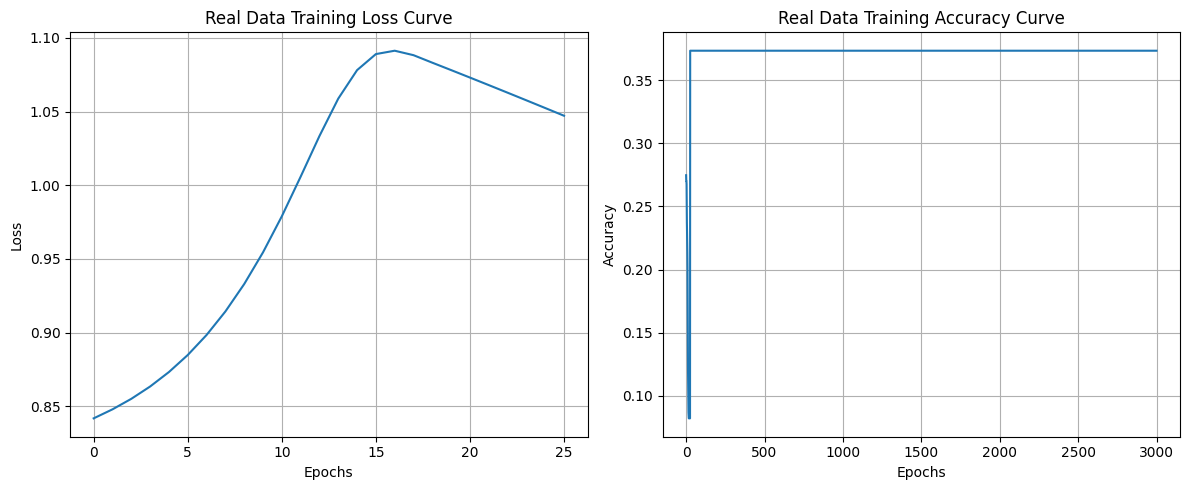

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history_real)
plt.title('Real Data Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracy_history_real)
plt.title('Real Data Training Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
predictions_test_real = predict(X_test_real_nn, W1_real, b1_real, W2_real, b2_real)
test_accuracy_real = np.mean(predictions_test_real == Y_test_real)
print(f"\nTest Accuracy (Real Data): {test_accuracy_real:.4f}")


Test Accuracy (Real Data): 0.3706


## Exercises

**TO-DO #1:** The dataset we chose is almost linearly separable. To see the true power of an MLP, we need non-linear data.Use sklearn.datasets.make_moons(n_samples=200, noise=0.1) to generate a "moon" shaped dataset. Train the ManualMLP on this new dataset. Does the loss decrease as effectively? How does the decision boundary look? Also try and see how it performs on the IRIS dataset.

**TO-DO #2:** Hyperparameter Tuning. Try changing learning rate (both decreasing and increasing) and see how the losses change, do they converge faster? Does the accuracy improve further? Describe what happens to the loss curve in both cases. Look for "Exploding Gradients" or "Slow Convergence."


Learning Rate = 0.001
Final Loss = 0.6247
Test Accuracy = 0.8000

Learning Rate = 0.01
Final Loss = 0.3334
Test Accuracy = 0.8267

Learning Rate = 0.1
Final Loss = 0.3193
Test Accuracy = 0.8133


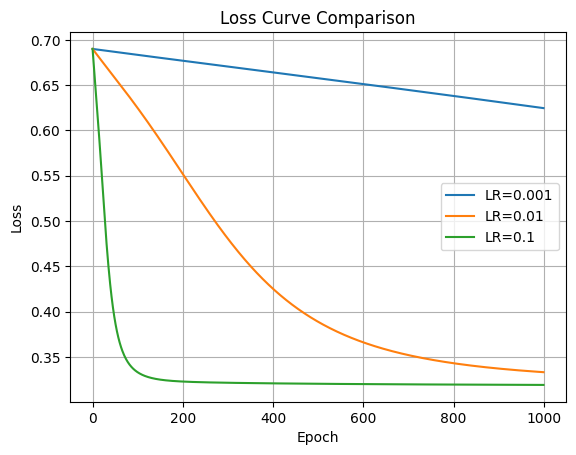

In [23]:
# TO-DO 1 & TO-DO 2 Experiments

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

X_moon, Y_moon = make_moons(n_samples=300,noise=0.20,)

X_train, X_test, Y_train, Y_test = train_test_split(X_moon,Y_moon,test_size=0.25,random_state=42,stratify=Y_moon)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape
X_train = X_train.T
X_test = X_test.T
Y_train = Y_train.reshape(1,-1)
Y_test = Y_test.reshape(1,-1)

learning_rates = [0.001, 0.01, 0.1]
for lr in learning_rates:
    np.random.seed(123)
    n_x = X_train.shape[0]
    n_h = 12
    n_y = 1

    W1 = np.random.randn(n_h,n_x)*0.1
    b1 = np.zeros((n_h,1))
    W2 = np.random.randn(n_y,n_h)*0.1
    b2 = np.zeros((n_y,1))
    losses = []

    for epoch in range(1000):
        A1,Z1 = forward_pass(X_train,W1,b1,tanh)
        A2,Z2 = forward_pass(A1,W2,b2,sigmoid)
        loss = -np.mean(Y_train*np.log(A2+1e-8)+(1-Y_train)*np.log(1-A2+1e-8))
        losses.append(loss)
        # Backward
        dZ2 = A2 - Y_train
        dW2 = np.dot(dZ2,A1.T)/X_train.shape[1]
        db2 = np.sum(dZ2,axis=1,keepdims=True)/X_train.shape[1]
        dA1 = np.dot(W2.T,dZ2)
        dA0,dW1,db1 = backward_pass(dA=dA1,Z=Z1,A_prev=X_train,W=W1,activation_derivative_fn=tanh_derivative,m=X_train.shape[1])

        W1 -= lr*dW1
        b1 -= lr*db1
        W2 -= lr*dW2
        b2 -= lr*db2

    A1,_ = forward_pass(X_test,W1,b1,tanh)
    A2,_ = forward_pass(A1,W2,b2,sigmoid)
    preds = (A2>0.5).astype(int)
    acc = np.mean(preds==Y_test)

    print(f"\nLearning Rate = {lr}")
    print(f"Final Loss = {losses[-1]:.4f}")
    print(f"Test Accuracy = {acc:.4f}")
    plt.plot(losses,label=f"LR={lr}")
plt.title("Loss Curve Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

LR = 0.001:

Slow convergence

Loss decreases gradually

Lower final accuracy

LR = 0.01:

Usually best balance

Smooth convergence

Good accuracy

LR = 0.1:

Fast convergence initially

May oscillate

If too large, loss may jump around

For the moon dataset, the decision boundary should become curved/non-linear, which demonstrates why an MLP is more powerful than linear models.